# LSTM predicting covariance between the 38 coins
uses 30min rolling window, same

here are the improvements:
1. instead of predicting the full 38x38 matrix, LLM has kindly suggested we take the upper triangle.
2. since we're using the upper triangle, LLM suggested taking cholesky. this will ensure that the matrix is consistently +ve definite => retaining its property as a cov matrix
3. minmax was replaced with standard scaling. reducing to minmax can compress the numbers to very small, possibly why the cov matrices came out very tiny as well. (it does not help that log returns already makes the values small). Hence, it was replaced with standard scaler. also! it's a nice match with the GARCH!
4. speaking of aligning w DCC GARCH, i also changed the model to predict correlation instead of cov so they now output the same thing

## initialising stuff

In [1]:
# importing packages
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Layer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folder_path = 'klines csv data/prices_cleaned'

# merging everything into a dataframe same code as DCC GARCH honestly
all_coins = sorted(os.listdir(folder_path))

glimpse = pd.read_csv(folder_path + "/" + all_coins[0])
print(all_coins[0])
print(glimpse.head())
print()
print(f"shape: {glimpse.shape}\n")

# remove KITEUSDT
if "KITEUSDT" in all_coins:
  all_coins.remove("KITEUSDT")

# filter for only folders containing csv files for currencies, one folder per currency in working directory
all_coins = [coin for coin in all_coins if not coin.endswith(".keras")]

# merge all data into single dataframe, row is timestep observation of price, column is currency
combined = pd.DataFrame({'time': glimpse.time})
for coin in all_coins:
  combined[coin] = pd.read_csv(folder_path + "/" + coin).sort_values(by='time').close

combined = combined.set_index('time')
print("merged df:")
combined.head()

ADAUSDT
   Unnamed: 0  close    time
0           0  1.165       0
1           1  1.155   86400
2           2  1.186  172800
3           3  1.212  259200
4           4  1.171  345600

shape: (1371, 3)

merged df:


,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,TRXUSDT,XRPUSDT
time,,,,,,,,
0,1.165,377.2,447.7,46283.49,3455.21,134.52,0.07494,0.8277
86400,1.155,372.5,437.2,45811.00,3443.77,132.49,0.07322,0.8240
172800,1.186,378.6,450.4,46407.35,3521.91,136.90,0.07312,0.8432
259200,1.212,376.2,447.6,46580.51,3519.50,132.14,0.07070,0.8260
345600,1.171,365.4,444.7,45497.55,3406.99,126.87,0.06928,0.8164


In [3]:
# CONFIGS
COV_WINDOW = 30          # rolling window size (minutes) for covariance estimation
LSTM_LOOKBACK = 30       # how many minutes of log returns the LSTM sees as input
TRAIN_RATIO = 0.8        # train/test split ratio
EPOCHS = 64
BATCH_SIZE = 32
CHECKPOINT_PATH = 'klines csv data/best_correlation_cholesky_LSTM.keras'

## rolling cov matrices
- log returns
- rolling window of 30mins same (`COV_WINDOW`)


In [4]:
log_returns_df = np.log(combined / combined.shift(1)).dropna() #using formula for log returns on lag by 1 timestep

print(f"Log returns shape: {log_returns_df.shape}")
print(f"  {log_returns_df.shape[0]} minutes × {log_returns_df.shape[1]} coins\n") #the df should have 1 less row

Log returns shape: (1370, 8)
  1370 minutes × 8 coins



In [5]:
# At each minute t, we compute the covariance matrix using
# log returns from t-COV_WINDOW+1 through t, then normalize it
# to a correlation matrix (bounded [-1, 1], diagonal = 1.0).

print(f"Computing rolling correlation matrices (window={COV_WINDOW})...")

n_currencies = len(combined.columns)
currency_names = combined.columns.tolist()
log_returns_values = log_returns_df.values  # numpy for speed

cov_matrices = []
for i in range(COV_WINDOW, len(log_returns_values) + 1):
    window = log_returns_values[i - COV_WINDOW:i]
    cov = np.cov(window, rowvar=False)
    cov_matrices.append(cov)

print(f"Generated {len(cov_matrices)} correlation matrices")
print(f"Each is {n_currencies}×{n_currencies} yay")

Computing rolling correlation matrices (window=30)...
Generated 1341 correlation matrices
Each is 8×8 yay


## additional data prep
- cholesky matrices
- standard scaling instead of minmax

In [6]:
# Convert covariance targets to Cholesky factors
n_tril = n_currencies * (n_currencies + 1) // 2  # unique lower-triangle values
tril_rows, tril_cols = np.tril_indices(n_currencies)

def cov_to_cholesky_flat(cov_matrix):
    """Decompose Σ → L (lower triangular), flatten lower triangle.
    Clips negative eigenvalues if Σ isn't perfectly positive definite."""
    try:
        L = np.linalg.cholesky(cov_matrix)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = np.linalg.eigh(cov_matrix)
        eigvals = np.maximum(eigvals, 1e-10)
        fixed = eigvecs @ np.diag(eigvals) @ eigvecs.T
        L = np.linalg.cholesky(fixed)
    return L[tril_rows, tril_cols]

def cholesky_flat_to_cov(flat_L):
    """Reconstruct Σ = L @ L^T from flattened lower triangle."""
    L = np.zeros((n_currencies, n_currencies))
    L[tril_rows, tril_cols] = flat_L
    return L @ L.T

print("Converting covariance matrices to Cholesky factors...")

y_cholesky = np.array([cov_to_cholesky_flat(cov) for cov in cov_matrices])

print(f"Target shape: {y_cholesky.shape}")
print(f"  (each target is {n_tril} values = lower triangle of {n_currencies}×{n_currencies})")
print(f"  vs original approach: {n_currencies**2} values (full matrix)")
print(f"  → {n_currencies**2 - n_tril} fewer outputs per prediction\n")

Converting covariance matrices to Cholesky factors...
Target shape: (1341, 36)
  (each target is 36 values = lower triangle of 8×8)
  vs original approach: 64 values (full matrix)
  → 28 fewer outputs per prediction



In [7]:
# Scale inputs: Student-t → uniform → inverse normal (for log returns)
from scipy.stats import t as student_t
from scipy.stats import norm

n_coins = log_returns_df.shape[1]
t_params = []

returns_values = log_returns_df.values
transformed_returns = np.zeros_like(returns_values)

for col in range(n_coins):
    series = returns_values[:, col]
    df, loc, scale = student_t.fit(series)
    t_params.append((df, loc, scale))
    uniform = student_t.cdf(series, df, loc=loc, scale=scale)
    uniform = np.clip(uniform, 1e-6, 1 - 1e-6)
    transformed_returns[:, col] = norm.ppf(uniform)

scaled_inputs = transformed_returns

# Scale targets: StandardScaler is fine for Cholesky factors
scaler_y = StandardScaler()
scaled_y_cholesky = scaler_y.fit_transform(y_cholesky)

## LSTM

### building

In [8]:
print("Building sequences...")

X_sequences = []
y_targets = []

for k in range(len(y_cholesky) - 1):  # -1 because we predict next step
    # The k-th covariance uses log returns ending at index (k + COV_WINDOW - 1)
    input_end = k + COV_WINDOW  # exclusive index into scaled_log_returns
    input_start = input_end - LSTM_LOOKBACK

    if input_start >= 0:
        X_sequences.append(scaled_inputs[input_start:input_end, :])
        y_targets.append(scaled_y_cholesky[k + 1])  # next covariance matrix

X_sequences = np.array(X_sequences)
y_targets = np.array(y_targets)

# Time-series split, we will use a 72/08/20 split
train_size = int(len(X_sequences) * TRAIN_RATIO)
X_train, X_test = X_sequences[:train_size], X_sequences[train_size:]
y_train, y_test = y_targets[:train_size], y_targets[train_size:]

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}\n")

Building sequences...
X_train: (1072, 30, 8)  y_train: (1072, 36)
X_test:  (268, 30, 8)  y_test:  (268, 36)



In [9]:
n_features_in = n_currencies

inputs = Input(shape=(LSTM_LOOKBACK, n_features_in)) #define network layers as composed functions on input x
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.3)(x)
x = LSTM(64, return_sequences=False)(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
cholesky_out = Dense(n_tril, name='cholesky_output')(x)

modelC = Model(inputs=inputs, outputs=cholesky_out)
modelC.compile(optimizer='adam', loss='mean_absolute_error')

print("Model summary:")
modelC.summary()

Model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cholesky_output (Dense)         │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,212 (227.39 KB)

 Trainable params: 58,212 (227.39 KB)

 Non-trainable params: 0 (0.00 B)

### training

In [10]:
checkpoint_cb = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    save_weights_only=False,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=24,
    restore_best_weights=True,
    verbose=1
)

history = modelC.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
    callbacks=[checkpoint_cb, early_stop_cb]
)

print(f"\nTraining complete. Best model saved to {CHECKPOINT_PATH}")

Epoch 1/64
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7480
Epoch 1: val_loss improved from None to 0.87058, saving model to klines csv data/best_correlation_cholesky_LSTM.keras

Epoch 1: finished saving model to klines csv data/best_correlation_cholesky_LSTM.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.7289 - val_loss: 0.8706
Epoch 2/64
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7003
Epoch 2: val_loss improved from 0.87058 to 0.85980, saving model to klines csv data/best_correlation_cholesky_LSTM.keras

Epoch 2: finished saving model to klines csv data/best_correlation_cholesky_LSTM.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.6785 - val_loss: 0.8598
Epoch 3/64
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6317
Epoch 3: val_loss improved from 0.85980 to 0.85368, saving model to klines csv data/best_correlation_cholesky_LSTM.keras

Epoch 3: finished saving model to klines csv data/best_correlation_cholesky_LSTM.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 

### prediction

In [11]:
# Predict and reconstruct valid covariance matrices
preds_scaled = modelC.predict(X_test)

# Inverse transform back to original Cholesky scale
preds_cholesky = scaler_y.inverse_transform(preds_scaled)
actual_cholesky = scaler_y.inverse_transform(y_test)

# Reconstruct full covariance matrices
preds_cov = np.array([cholesky_flat_to_cov(p) for p in preds_cholesky])
actual_cov = np.array([cholesky_flat_to_cov(a) for a in actual_cholesky])

# Flatten for metric computation
predictions_flat = preds_cov.reshape(len(preds_cov), -1)
actuals_flat = actual_cov.reshape(len(actual_cov), -1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


## saving matrices computed
as .npy file

In [12]:
# Reconstruct train set correlation matrices from Cholesky factors
train_cholesky = scaler_y.inverse_transform(y_train)
train_cov = np.array([cholesky_flat_to_cov(c) for c in train_cholesky])

# Save: train actuals + test predicted (one continuous timeline)
all_cov_matrices = np.concatenate([train_cov, preds_cov], axis=0)
np.save('klines csv data/lstm_cov_matrices.npy', all_cov_matrices)

# Also save actuals separately for comparison, and currency names
# np.save('corr_matrices_test_actual.npy', actual_corr)
# np.save('currency_names.npy', np.array(currency_names))

print(f"\nSaved covariance matrices:")
print(f"  all_cov_matrices.npy        — {all_cov_matrices.shape}")
print(f"    [{train_cov.shape[0]} train actual] + [{preds_cov.shape[0]} test predicted]")
# print(f"  corr_matrices_test_actual.npy — {actual_corr.shape}")
# print(f"  currency_names.npy            — {len(currency_names)} coins")


Saved covariance matrices:
  all_cov_matrices.npy        — (1340, 8, 8)
    [1072 train actual] + [268 test predicted]


## evaluations
- validate that cov matrices are semi def
- plot distributions
- RMSE evals

In [13]:
# Validate positive semi-definiteness
n_invalid = 0
for i in range(len(preds_cov)):
    eigvals = np.linalg.eigvalsh(preds_cov[i])
    if np.any(eigvals < -1e-10):
        n_invalid += 1

print(f"\nValidity check: {n_invalid}/{len(preds_cov)} matrices are NOT positive semi-definite")
if n_invalid == 0:
    print("All predicted correlation matrices are valid!")


Validity check: 0/268 matrices are NOT positive semi-definite
All predicted correlation matrices are valid!


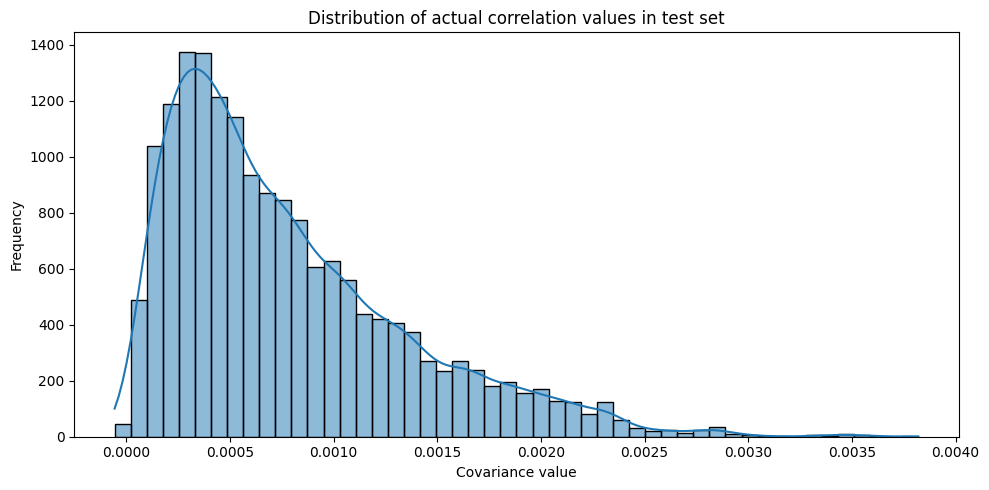

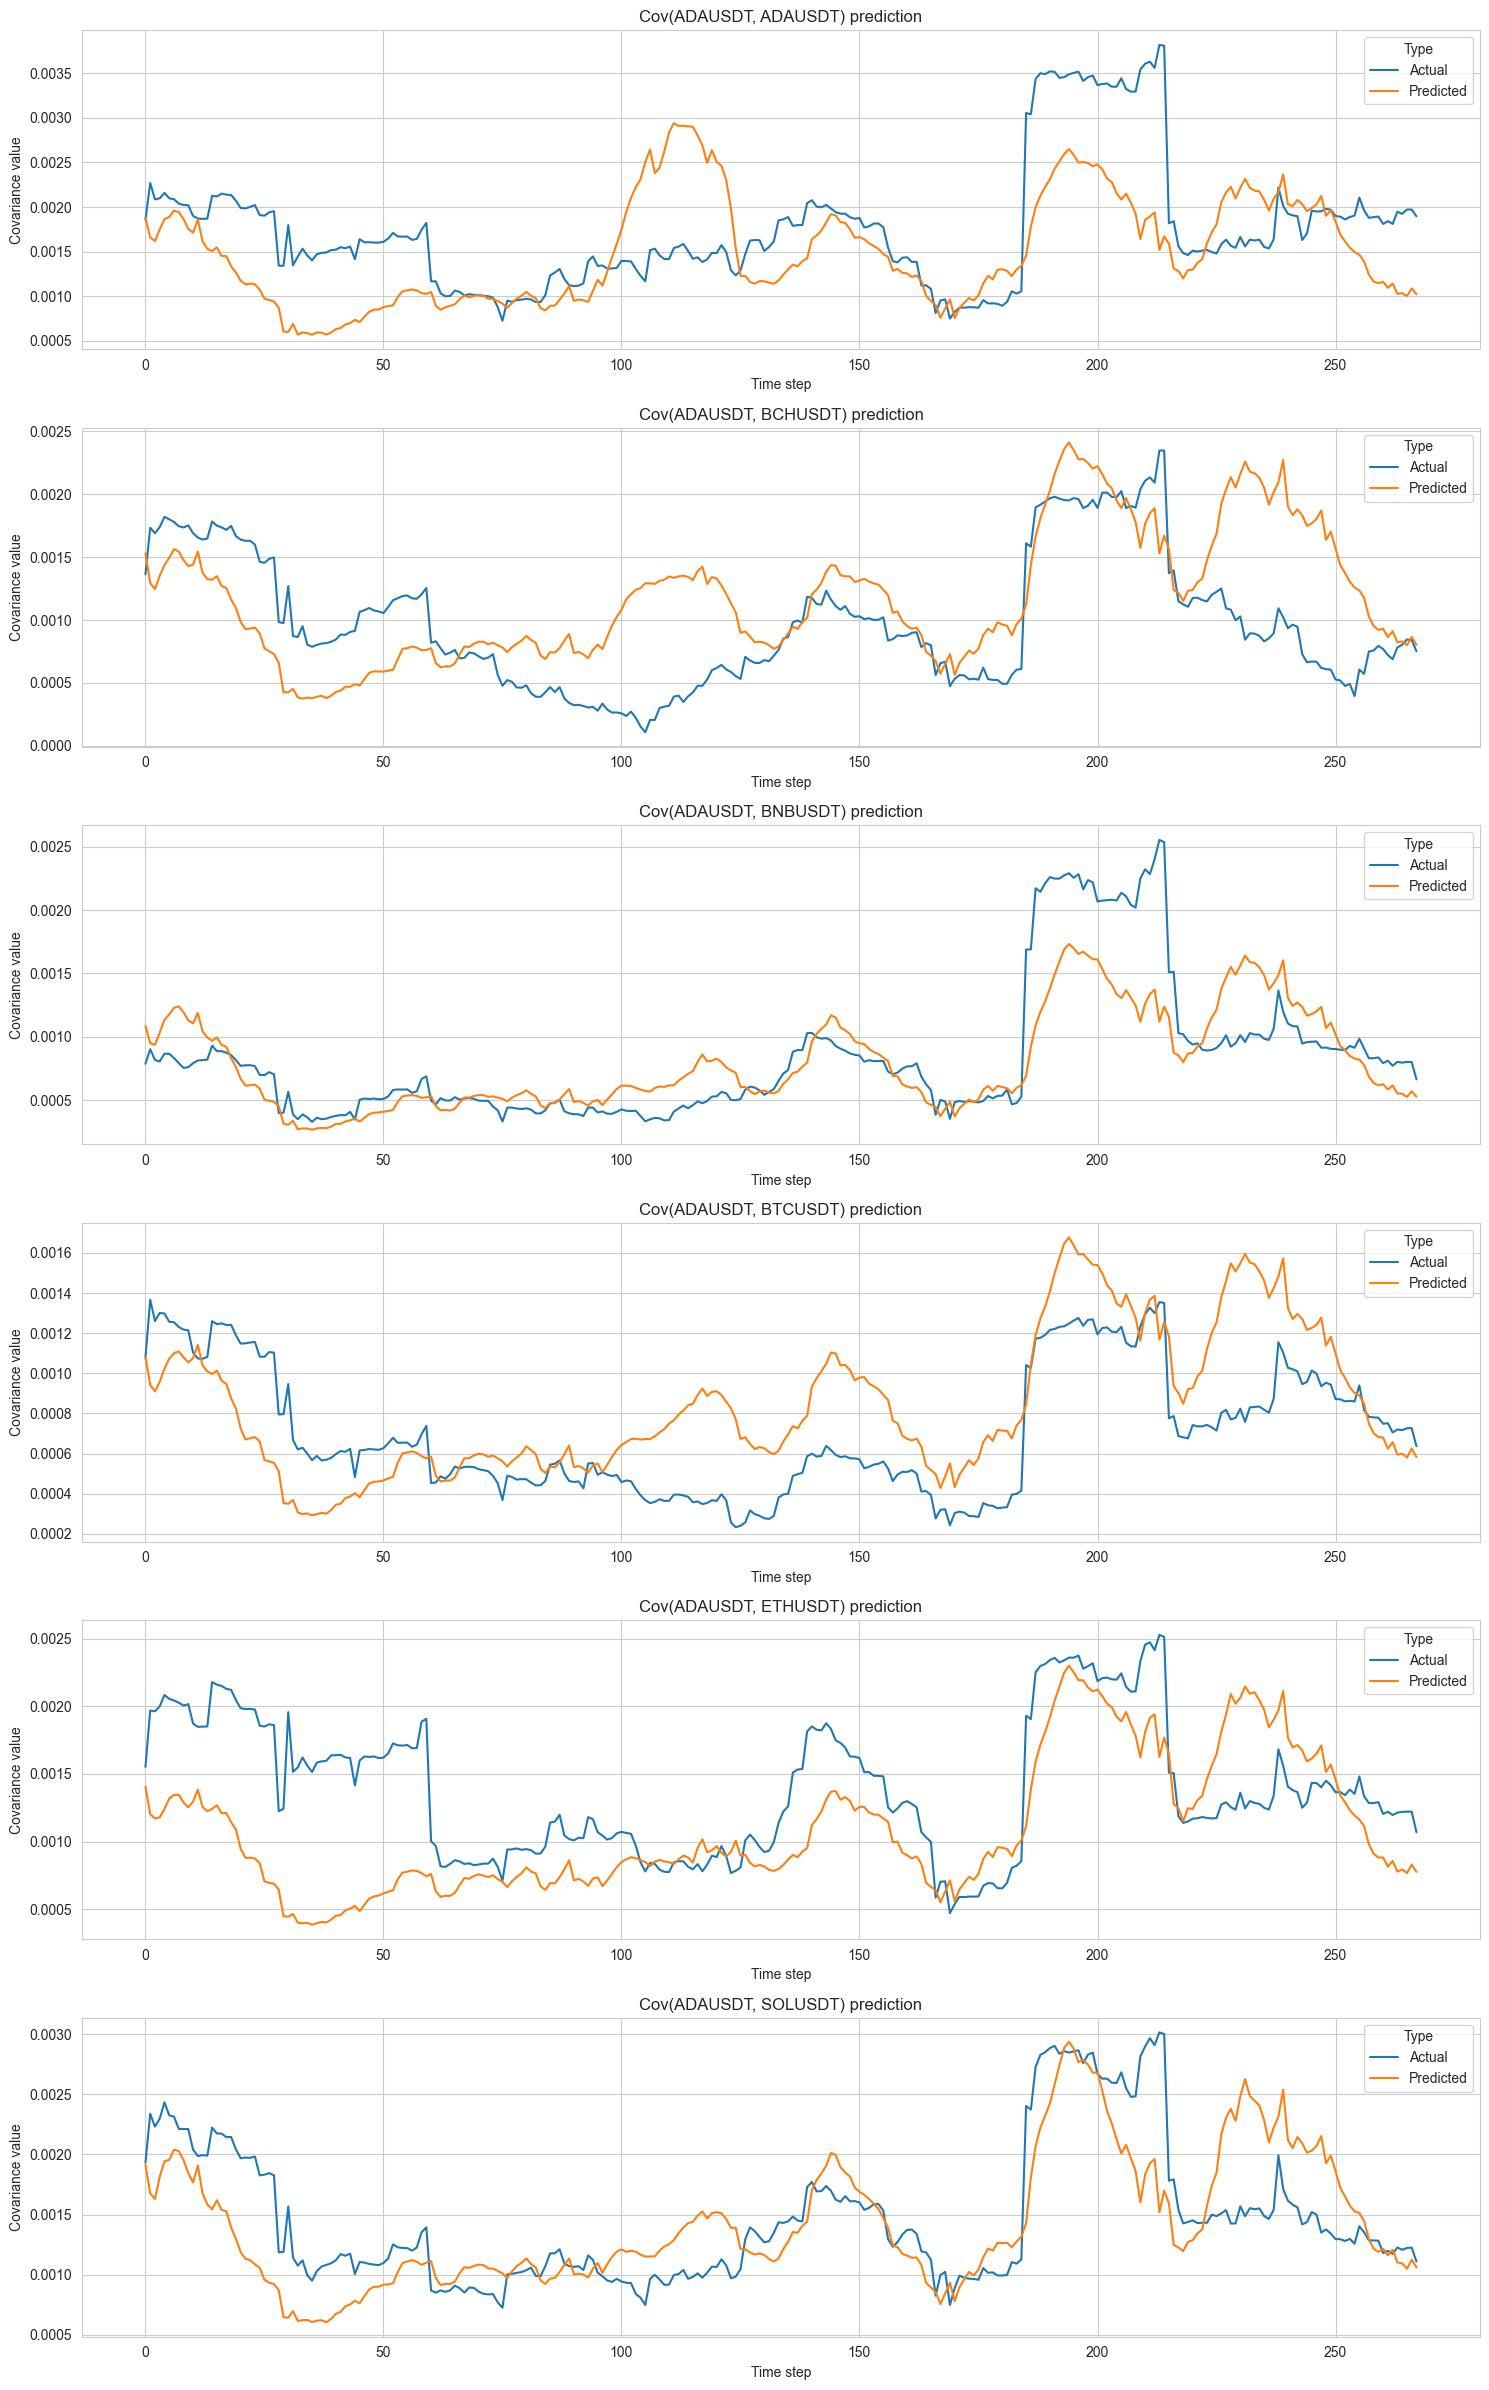

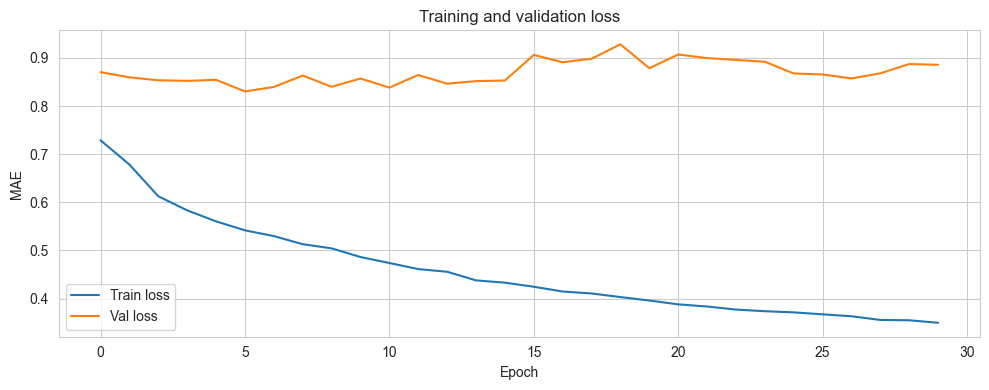


RMSE across all covariance terms: 0.00043799

RMSE per covariance term (showing first 20):
  Cov(ADAUSDT, ADAUSDT): 0.00070948
  Cov(ADAUSDT, BCHUSDT): 0.00054995
  Cov(ADAUSDT, BNBUSDT): 0.00033909
  Cov(ADAUSDT, BTCUSDT): 0.00031044
  Cov(ADAUSDT, ETHUSDT): 0.00056361
  Cov(ADAUSDT, SOLUSDT): 0.00042763
  Cov(ADAUSDT, TRXUSDT): 0.00023781
  Cov(ADAUSDT, XRPUSDT): 0.00049646
  Cov(BCHUSDT, ADAUSDT): 0.00054995
  Cov(BCHUSDT, BCHUSDT): 0.00066579
  Cov(BCHUSDT, BNBUSDT): 0.00033918
  Cov(BCHUSDT, BTCUSDT): 0.00049653
  Cov(BCHUSDT, ETHUSDT): 0.00058186
  Cov(BCHUSDT, SOLUSDT): 0.00066257
  Cov(BCHUSDT, TRXUSDT): 0.00030566
  Cov(BCHUSDT, XRPUSDT): 0.00055065
  Cov(BNBUSDT, ADAUSDT): 0.00033909
  Cov(BNBUSDT, BCHUSDT): 0.00033918
  Cov(BNBUSDT, BNBUSDT): 0.00051327
  Cov(BNBUSDT, BTCUSDT): 0.00025942


In [14]:
# Distribution of actual values
plt.figure(figsize=(10, 5))
sns.histplot(actuals_flat.flatten(), bins=50, kde=True)
plt.title('Distribution of actual correlation values in test set')
plt.xlabel('Covariance value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Actual vs predicted for selected pairs
num_to_plot = 6
plt.figure(figsize=(15, num_to_plot * 4))
sns.set_style("whitegrid")

for i in range(num_to_plot):
    plt.subplot(num_to_plot, 1, i + 1)
    row_idx = i // n_currencies
    col_idx = i % n_currencies
    label = f'Cov({currency_names[row_idx]}, {currency_names[col_idx]})'

    plot_data = pd.DataFrame({
        'Time Step': range(len(actuals_flat)),
        'Actual': actuals_flat[:, i],
        'Predicted': predictions_flat[:, i]
    })
    melted = plot_data.melt(id_vars=['Time Step'], var_name='Type', value_name='Covariance Value')
    sns.lineplot(data=melted, x='Time Step', y='Covariance Value', hue='Type', ax=plt.gca())
    plt.title(f'{label} prediction')
    plt.xlabel('Time step')
    plt.ylabel('Covariance value')

plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# Overall RMSE
rmse_overall = np.sqrt(mean_squared_error(actuals_flat, predictions_flat))
print(f"\nRMSE across all covariance terms: {rmse_overall:.8f}")

# Per-pair RMSE
rmse_per_term = []
for i in range(n_currencies ** 2):
    rmse_val = np.sqrt(mean_squared_error(actuals_flat[:, i], predictions_flat[:, i]))
    r = i // n_currencies
    c = i % n_currencies
    label = f'Cov({currency_names[r]}, {currency_names[c]})'
    rmse_per_term.append((label, rmse_val))

print("\nRMSE per covariance term (showing first 20):")
for term, val in rmse_per_term[:20]:
    print(f"  {term}: {val:.8f}")